In [338]:
import pandas as pd
pd.set_option('display.max_rows', 200)    
pd.set_option('display.max_columns', 200) 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

### Data Cleaning

In [339]:
data = pd.read_csv("./dataset/shopify.csv")

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\2529528072.py:1: DtypeWarning: Columns (10,35,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,125,126,127,128,129,130,131,132,133,134,135,136,137,138) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("./dataset/shopify.csv")


In [340]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7582 entries, 0 to 7581
Columns: 156 entries, Handle to Compare At Price
dtypes: float64(28), int64(1), object(127)
memory usage: 9.0+ MB


In [341]:
data.describe()

,Option2 Linked To,Option3 Name,Option3 Value,Option3 Linked To,Variant Grams,Variant Price,Variant Compare At Price,Image Position,Google Shopping / Google Product Category,Google Shopping / Gender,Google Shopping / MPN,Google Shopping / Condition,Google Shopping / Custom Product,Google Shopping / Custom Label 0,Google Shopping / Custom Label 1,Google Shopping / Custom Label 2,Google Shopping / Custom Label 3,Google Shopping / Custom Label 4,Specification (product.metafields.custom.specification),Google: Custom Product (product.metafields.mm-google-shopping.custom_product),Vehicle engine part features (product.metafields.shopify.vehicle-engine-part-features),Variant Tax Code,Cost per item,Price / United Arab Emirates,Compare At Price / United Arab Emirates,Price / International,Compare At Price / International,Product Rating Count,Compare At Price
count,0.0,0.0,0.0,0.0,3275.000000,7582.000000,7.582000e+03,7099.000000,514.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7582.000000,7582.000000,0.0,7.582000e+03,0.0,7582.000000,7.582000e+03
mean,NaN,NaN,NaN,NaN,1109.176573,5359.550223,5.404575e+03,3.490069,7661.258755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5304.249789,5359.550223,NaN,5.369731e+03,NaN,252.290952,5.414695e+03
std,NaN,NaN,NaN,NaN,21297.678422,17268.393880,1.726876e+04,2.494063,43999.535256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17268.136658,17268.393880,NaN,1.726848e+04,NaN,144.562122,1.726873e+04
min,NaN,NaN,NaN,NaN,0.000000,-29.910000,1.150000e+00,1.000000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-112.480000,-29.910000,NaN,-4.605000e+01,NaN,0.000000,-4.040000e+00
25%,NaN,NaN,NaN,NaN,0.000000,151.730000,1.989025e+02,2.000000,919.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.525000,151.730000,NaN,1.638900e+02,NaN,127.000000,2.080200e+02
50%,NaN,NaN,NaN,NaN,0.000000,383.195000,4.262400e+02,3.000000,2977.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,327.095000,383.195000,NaN,3.914900e+02,NaN,256.000000,4.362250e+02
75%,NaN,NaN,NaN,NaN,0.000000,927.840000,9.686550e+02,5.000000,6091.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,875.227500,927.840000,NaN,9.469750e+02,NaN,376.000000,9.764025e+02
max,NaN,NaN,NaN,NaN,500000.000000,999983.750000,1.000062e+06,21.000000,503031.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,999895.330000,999983.750000,NaN,1.000016e+06,NaN,500.000000,1.000012e+06


In [342]:
data.isna().sum()

Handle                                                                                                                 0
Title                                                                                                               6029
Body (HTML)                                                                                                         6031
Vendor                                                                                                              6029
Product Category                                                                                                       0
Type                                                                                                                7485
Tags                                                                                                                6527
Published                                                                                                           6029
Option1 Name                    

In [343]:
threshold = len(df)-6000

In [344]:
df = data.dropna(axis=1, thresh=threshold)

In [345]:
df.isna().sum()

Handle                             0
Product Category                   0
Option1 Value                   4307
Variant SKU                     5821
Variant Grams                   4307
Variant Inventory Tracker       4538
Variant Inventory Policy        4307
Variant Fulfillment Service     4307
Variant Price                      0
Variant Compare At Price           0
Variant Requires Shipping       4307
Variant Taxable                 4307
Variant Barcode                 4740
Image Src                        483
Image Position                   483
Image Alt Text                  3454
Variant Weight Unit             4307
Cost per item                      0
Price / United Arab Emirates       0
Price / International              0
Status                             0
Product Rating Count               0
Material                           0
Color                              0
Size                               0
Fit                                0
Compare At Price                   0
d

In [346]:
df.drop("Variant Inventory Tracker",axis = 1,inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\1664652011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop("Variant Inventory Tracker",axis = 1,inplace=True)


The variant Price is always greater thatn the cost per item, assume that the variant price 
is the price of the product for seller and the cost per item is for the buyers and users

Since both have similar values with a values decresed by few units lets replace the feature variant r[rice with the cost per item

In [78]:
df.drop("Variant Price",axis = 1,inplace = True)

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\3281102028.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop("Variant Price",axis = 1,inplace = True)


<Axes: xlabel='None', ylabel='Variant Price'>

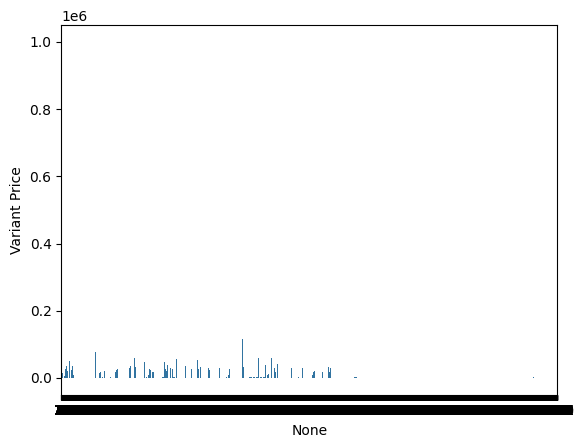

In [71]:
sns.barplot(y = "Variant Price",x = df.index,data = df)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7582 entries, 0 to 7581
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Handle                        7582 non-null   object 
 1   Product Category              7582 non-null   object 
 2   Option1 Value                 3275 non-null   object 
 3   Variant Grams                 3275 non-null   float64
 4   Variant Inventory Policy      7582 non-null   object 
 5   Variant Fulfillment Service   3275 non-null   object 
 6   Variant Compare At Price      7582 non-null   float64
 7   Variant Requires Shipping     3275 non-null   object 
 8   Variant Taxable               3275 non-null   object 
 9   Variant Weight Unit           3275 non-null   object 
 10  Cost per item                 7582 non-null   float64
 11  Price / United Arab Emirates  7582 non-null   float64
 12  Price / International         7582 non-null   float64
 13  Sta

In [348]:
selected = df[["Cost per item","Price / United Arab Emirates","Price / International","Status","Product Rating Count","Material","Color","Size","Fit","Compare At Price"]]

In [302]:
selected

,Cost per item,Price / United Arab Emirates,Price / International,Status,Product Rating Count,Material,Color,Size,Fit,Compare At Price
0,763.71,843.07,885.61,active,166,Rubber,Black,Small,Universal Fit,892.44
1,818.05,839.04,809.97,active,298,Plastic,Silver,Medium,Universal Fit,860.63
2,759.17,827.82,824.51,active,484,Carbon Fiber,Silver,Medium,Universal Fit,927.46
3,13969.34,14021.65,14007.24,active,304,Plastic,Silver,Medium,Universal Fit,14042.97
4,13971.14,14032.99,14057.69,active,170,Rubber,Gray,XL,Custom Fit,14109.82
...,...,...,...,...,...,...,...,...,...,...
7577,246.83,306.82,318.48,active,250,Plastic,Silver,Medium,Custom Fit,333.22
7578,311.55,336.61,328.54,active,469,Carbon Fiber,Gray,Medium,Custom Fit,403.75
7579,280.46,347.90,396.48,active,492,Aluminum,Black,Small,Custom Fit,419.87
7580,260.61,334.05,318.56,active,252,Rubber,Black,Medium,Universal Fit,377.84


In [303]:
selected["Fit"].unique()

array(['Universal Fit', 'Custom Fit'], dtype=object)

In [304]:
selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7582 entries, 0 to 7581
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Cost per item                 7582 non-null   float64
 1   Price / United Arab Emirates  7582 non-null   float64
 2   Price / International         7582 non-null   float64
 3   Status                        7582 non-null   object 
 4   Product Rating Count          7582 non-null   int64  
 5   Material                      7582 non-null   object 
 6   Color                         7582 non-null   object 
 7   Size                          7582 non-null   object 
 8   Fit                           7582 non-null   object 
 9   Compare At Price              7582 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 592.5+ KB


### Data Encoding

In [305]:
stat = LabelEncoder()
selected["Status"] = stat.fit_transform(selected["Status"])

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\3787567050.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected["Status"] = stat.fit_transform(selected["Status"])


In [306]:
mat = LabelEncoder()
selected["Material"] = mat.fit_transform(selected["Material"])

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\1024387838.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected["Material"] = mat.fit_transform(selected["Material"])


In [307]:
col = LabelEncoder()
selected["Color"] = col.fit_transform(selected["Color"])

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\1195015217.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected["Color"] = col.fit_transform(selected["Color"])


In [308]:
size = LabelEncoder()
selected["Size"] = size.fit_transform(selected["Size"])

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\2779228674.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected["Size"] = size.fit_transform(selected["Size"])


In [309]:
fit = LabelEncoder()
selected["Fit"] = fit.fit_transform(selected["Fit"])

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\3601183161.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected["Fit"] = fit.fit_transform(selected["Fit"])


In [260]:
correlated = selected.corr()

In [349]:
selected.drop("Status",axis = 1,inplace = True)

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\2523093642.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected.drop("Status",axis = 1,inplace = True)


<Axes: >

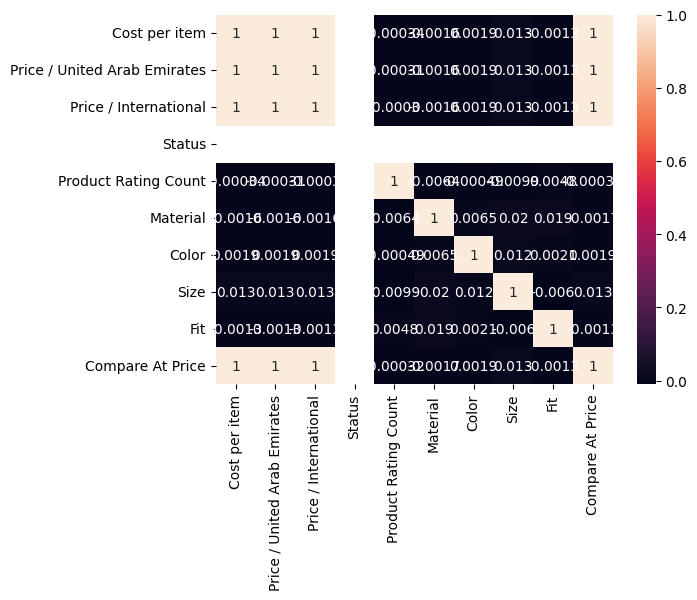

In [261]:
sns.heatmap(data = correlated,annot = True)

In [313]:
selected.describe()

,Cost per item,Product Rating Count,Material,Color,Size,Fit,Compare At Price
count,7582.000000,7582.000000,7582.000000,7582.000000,7582.000000,7582.000000,7.582000e+03
mean,5304.249789,252.290952,2.008045,1.995779,1.499604,0.505671,5.414695e+03
std,17268.136658,144.562122,1.420751,1.412714,1.111600,0.500001,1.726873e+04
min,-112.480000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.040000e+00
25%,98.525000,127.000000,1.000000,1.000000,1.000000,0.000000,2.080200e+02
50%,327.095000,256.000000,2.000000,2.000000,1.000000,1.000000,4.362250e+02
75%,875.227500,376.000000,3.000000,3.000000,2.000000,1.000000,9.764025e+02
max,999895.330000,500.000000,4.000000,4.000000,3.000000,1.000000,1.000012e+06


In [170]:
backup = selected

In [312]:
selected.drop("Price / United Arab Emirates",axis =1,inplace = True)
selected.drop("Price / International",axis =1,inplace = True)

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\1928615220.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected.drop("Price / United Arab Emirates",axis =1,inplace = True)
C:\Users\USER\AppData\Local\Temp\ipykernel_22464\1928615220.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected.drop("Price / International",axis =1,inplace = True)


In [314]:
selected = selected[selected['Cost per item'] >= 0]

## K-Means Clustering

In [272]:
wcss = []
for k in range(1,20):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(selected)
    wcss.append(kmeans.inertia_)
print(wcss)

[4497787651417.194, 2465451009362.0015, 1777045693135.575, 264559298030.23975, 116640080729.59273, 63882722725.97945, 47012865283.73055, 32242317593.7753, 21193098212.636997, 16560771528.49798, 14368554227.604904, 11590139531.355793, 9589435832.862051, 8937666461.353819, 7477083456.360988, 7252779689.987226, 6625725691.716615, 5292824723.190496, 4493921863.423934]


<Axes: >

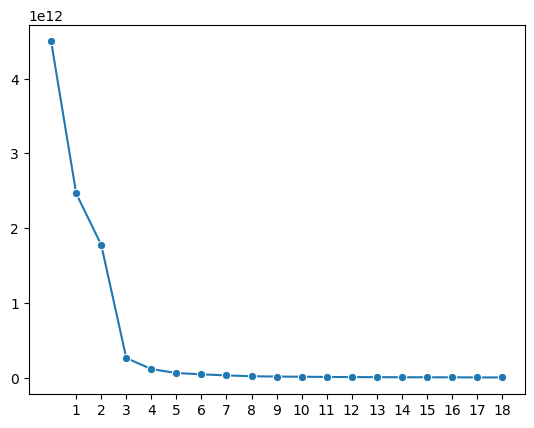

In [273]:
plt.xticks(range(1, len(wcss) + 1))
sns.lineplot(x=range(0,len(wcss)),y=wcss,marker = "o")

using the elbow methioow we got steady decrease untill the point k = assume that there is a natural cluster
of 3

In [176]:
best_k = 0
best_score = -1
scores = []

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(selected)
    
    score = silhouette_score(selected, labels)
    scores.append((k, score))

    print(f"k = {k}, Silhouette Score = {score:.4f}")
    
    if score > best_score:
        best_k = k
        best_score = score

print(f"\nBest number of clusters: k = {best_k} with Silhouette Score = {best_score:.4f}")

k = 2, Silhouette Score = 0.9033
k = 3, Silhouette Score = 0.9140
k = 4, Silhouette Score = 0.9166
k = 5, Silhouette Score = 0.9209
k = 6, Silhouette Score = 0.9038
k = 7, Silhouette Score = 0.8983
k = 8, Silhouette Score = 0.8878
k = 9, Silhouette Score = 0.8860
k = 10, Silhouette Score = 0.8877
k = 11, Silhouette Score = 0.8839
k = 12, Silhouette Score = 0.8699
k = 13, Silhouette Score = 0.7097
k = 14, Silhouette Score = 0.7078
k = 15, Silhouette Score = 0.7114
k = 16, Silhouette Score = 0.7117
k = 17, Silhouette Score = 0.7126
k = 18, Silhouette Score = 0.7149
k = 19, Silhouette Score = 0.7167

Best number of clusters: k = 5 with Silhouette Score = 0.9209


silhouette scre says the best cluster is at k =5 

lets start by choosig the cluster as 3

In [315]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(selected)

KMeans(n_clusters=3, random_state=42)

In [316]:
labels = model.labels_

In [317]:
selected["Clusters"] = labels

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\637941343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected["Clusters"] = labels


In [318]:
cluster_1 = selected.loc[(selected["Clusters"] == 0) ,:]
cluster_2 = selected.loc[(selected["Clusters"] == 1) ,:]
cluster_3 = selected.loc[(selected["Clusters"] == 2) ,:]

majority of the customers who boght the products bought color 3, size 3, fit 1 and their discount rate doesn't
seem that high which means they are bought at their actual price

These customer choose to buy products within the price range of 1600-76000

the majority of the peoples are included in the cluster2 here looking at the purchase we can see
they choose to purchase commodities with 50% discount and procducts withing the price range of 0- 16000 majority buying products with a price of 559
by looking at their colour and materila prerferences they chose to go with color 3 , size 2 , fit 1 and material 3

These people choose to buy the products of price range 100000-1000000 on majority they spent above 120000
similarly they are not buying based on the discont rates and they choose to prefer matreial 4 , color 4,size 4 and fit 1
and they are the least no of users cliuster we have

#### Cluster 1

In [278]:
cluster_1

,Cost per item,Product Rating Count,Material,Color,Size,Fit,Compare At Price,Clusters
19,29885.15,363,4,1,1,1,30030.39,0
20,29965.69,172,2,4,1,0,30030.46,0
21,29928.26,465,3,1,1,0,29999.05,0
22,29955.36,118,2,0,3,1,30056.80,0
23,29856.01,236,2,2,3,1,30029.65,0
...,...,...,...,...,...,...,...,...
4138,32946.43,400,4,0,3,0,32999.47,0
4139,32905.21,122,2,2,3,0,33082.12,0
4140,32908.00,466,3,0,2,1,33008.10,0
4141,32856.58,487,3,1,3,1,33022.33,0


In [183]:
cluster_1['Discount Percentage'] = (((cluster_1['Compare At Price'] - cluster_1['Cost per item']) / cluster_1['Compare At Price']) * 100)

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\4068591390.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_1['Discount Percentage'] = (((cluster_1['Compare At Price'] - cluster_1['Cost per item']) / cluster_1['Compare At Price']) * 100)


In [279]:
cluster_1.describe()

,Cost per item,Product Rating Count,Material,Color,Size,Fit,Compare At Price,Clusters
count,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.0
mean,31645.084933,252.819656,1.981870,1.963740,1.499046,0.524809,31757.543588,0.0
std,11594.005232,144.652226,1.397451,1.436535,1.127921,0.499623,11594.339225,0.0
min,16891.270000,1.000000,0.000000,0.000000,0.000000,0.000000,16986.390000,0.0
25%,23924.657500,121.000000,1.000000,1.000000,0.000000,0.000000,24043.555000,0.0
50%,28983.275000,254.500000,2.000000,2.000000,1.500000,1.000000,29093.315000,0.0
75%,34926.292500,382.000000,3.000000,3.000000,3.000000,1.000000,35037.697500,0.0
max,76016.230000,500.000000,4.000000,4.000000,3.000000,1.000000,76113.700000,0.0


majority of the customers who boght the products bought color 3, size 3, fit 1 and their discount rate doesn't
seem that high which means they are bought at their actual price

These customer choose to buy products within the price range of 1600-76000

In [322]:
size_1 = size.inverse_transform([3])[0]
color_1 = col.inverse_transform([3])[0]
fit_1 = fit.inverse_transform([1])[0]
material_1 = mat.inverse_transform([3])[0]

In [323]:
print(" majority bought size :- ",size_1,"\n majority bought color :- ",color_1,"\n majority bought fit :- ",fit_1,"\n maojority bought material :- ",material_1)

 majority bought size :-  XL 
 majority bought color :-  Red 
 majority bought fit :-  Universal Fit 
 maojority bought material :-  Rubber


In [335]:
cluster_1["Cost per item"].sum()

np.float64(33164049.009999998)

med class customers spent a total of 33164049 and per person spend about 31,649

#### Cluster 2

In [186]:
cluster_2['Discount Percentage'] = ((cluster_2['Compare At Price'] - cluster_2["Cost per item"]) / cluster_2['Compare At Price']) * 100

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\14890947.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_2['Discount Percentage'] = ((cluster_2['Compare At Price'] - cluster_2["Cost per item"]) / cluster_2['Compare At Price']) * 100


In [280]:
cluster_2.describe()

,Cost per item,Product Rating Count,Material,Color,Size,Fit,Compare At Price,Clusters
count,6119.000000,6119.000000,6119.000000,6119.000000,6119.000000,6119.000000,6119.000000,6119.0
mean,633.921866,252.272267,2.009152,1.998366,1.495833,0.504167,742.801621,1.0
std,1615.500690,144.637040,1.422481,1.405983,1.109385,0.500023,1616.293782,0.0
min,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,45.360000,1.0
25%,100.465000,128.000000,1.000000,1.000000,1.000000,0.000000,210.435000,1.0
50%,262.890000,256.000000,2.000000,2.000000,1.000000,1.000000,373.600000,1.0
75%,559.375000,376.000000,3.000000,3.000000,2.000000,1.000000,671.280000,1.0
max,16008.210000,500.000000,4.000000,4.000000,3.000000,1.000000,16097.680000,1.0


the majority of the peoples are included in the cluster2 here looking at the purchase we can see
they choose to purchase commodities with 50% discount and procducts withing the price range of 0- 16000 majority buying products with a price of 559
by looking at their colour and materila prerferences they chose to go with color 3 , size 2 , fit 1 and material 3

In [326]:
size_2 = size.inverse_transform([2])[0]
color_2 = col.inverse_transform([3])[0]
fit_2 = fit.inverse_transform([1])[0]
material_2 = mat.inverse_transform([3])[0]

In [327]:
print(" majority bought size :- ",size_2,"\n majority bought color :- ",color_2,"\n majority bought fit :- ",fit_2,"\n maojority bought material :- ",material_2)

 majority bought size :-  Small 
 majority bought color :-  Red 
 majority bought fit :-  Universal Fit 
 maojority bought material :-  Rubber


In [336]:
cluster_2["Cost per item"].sum()

np.float64(3878967.9)

low class customers spent a total of 3878967 and a per person spend about 633 

#### Cluster 3

In [281]:
cluster_3['Discount Percentage'] = ((cluster_3['Compare At Price'] - cluster_3["Cost per item"]) / cluster_3['Compare At Price']) * 100

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\3513069694.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_3['Discount Percentage'] = ((cluster_3['Compare At Price'] - cluster_3["Cost per item"]) / cluster_3['Compare At Price']) * 100


In [282]:
cluster_3.describe()

,Cost per item,Product Rating Count,Material,Color,Size,Fit,Compare At Price,Clusters,Discount Percentage
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,1.900000e+01,19.0,19.000000
mean,167570.566842,261.105263,2.947368,2.947368,1.368421,0.421053,1.676811e+05,2.0,0.086765
std,201621.913200,119.763143,1.393385,1.311220,1.382852,0.507257,2.016233e+05,0.0,0.032225
min,114894.030000,62.000000,0.000000,0.000000,0.000000,0.000000,1.149779e+05,2.0,0.011632
25%,119877.620000,172.000000,2.000000,2.000000,0.000000,0.000000,1.199831e+05,2.0,0.068933
50%,119976.770000,253.000000,4.000000,4.000000,1.000000,0.000000,1.200814e+05,2.0,0.078873
75%,128922.705000,352.500000,4.000000,4.000000,3.000000,1.000000,1.290261e+05,2.0,0.106406
max,999895.330000,451.000000,4.000000,4.000000,3.000000,1.000000,1.000012e+06,2.0,0.154092


These people choose to buy the products of price range 100000-1000000 on majority they spent above 120000
similarly they are not buying based on the discont rates and they choose to prefer matreial 4 , color 4,size 3 and fit 1
and they are the least no of users cliuster we have

In [330]:
size_3 = size.inverse_transform([3])[0]
color_3 = col.inverse_transform([4])[0]
fit_3 = fit.inverse_transform([1])[0]
material_3 = mat.inverse_transform([4])[0]

In [331]:
print(" majority bought size :- ",size_3,"\n majority bought color :- ",color_3,"\n majority bought fit :- ",fit_3,"\n maojority bought material :- ",material_3)

 majority bought size :-  XL 
 majority bought color :-  Silver 
 majority bought fit :-  Universal Fit 
 maojority bought material :-  Steel


In [337]:
cluster_3["Cost per item"].sum()

np.float64(3183840.77)

high class customers spent a total of 3183840 and by avearge each person spent about  167570

### Silhouette method based

In [194]:
model_s = KMeans(n_clusters=5, random_state=42)
model_s.fit(selected)

KMeans(n_clusters=5, random_state=42)

In [205]:
selected["Clusters"] = model_s.labels_

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\2320047809.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected["Clusters"] = model_s.labels_


In [206]:
cluster_1 = selected.loc[(selected["Clusters"] == 0) ,:]
cluster_2 = selected.loc[(selected["Clusters"] == 1) ,:]
cluster_3 = selected.loc[(selected["Clusters"] == 2) ,:]
cluster_4 = selected.loc[(selected["Clusters"] == 3) ,:]
cluster_5 = selected.loc[(selected["Clusters"] == 4) ,:]

#### Cluster 1

In [207]:
cluster_1['Discount Percentage'] = (((cluster_1['Compare At Price'] - cluster_1['Cost per item']) / cluster_1['Compare At Price']) * 100)

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\4068591390.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_1['Discount Percentage'] = (((cluster_1['Compare At Price'] - cluster_1['Cost per item']) / cluster_1['Compare At Price']) * 100)


In [208]:
cluster_1.describe()

,Cost per item,Product Rating Count,Material,Color,Size,Fit,Compare At Price,Clusters,Discount Percentage
count,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.0,910.000000
mean,27394.302978,254.008791,2.001099,1.989011,1.465934,0.525275,27506.827593,0.0,0.427254
std,5685.416928,143.915182,1.405239,1.448754,1.139569,0.499635,5686.649664,0.0,0.169193
min,14023.400000,1.000000,0.000000,0.000000,0.000000,0.000000,14093.210000,0.0,0.062678
25%,22922.202500,128.250000,1.000000,1.000000,0.000000,0.000000,23042.642500,0.0,0.303673
50%,27940.925000,256.500000,2.000000,2.000000,1.000000,1.000000,28069.650000,0.0,0.408753
75%,30984.930000,381.000000,3.000000,3.000000,3.000000,1.000000,31112.465000,0.0,0.530438
max,38017.110000,500.000000,4.000000,4.000000,3.000000,1.000000,38125.910000,0.0,1.124508


#### Cluster 2

In [209]:
cluster_2['Discount Percentage'] = (((cluster_2['Compare At Price'] - cluster_2['Cost per item']) / cluster_2['Compare At Price']) * 100)

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\3263611223.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_2['Discount Percentage'] = (((cluster_2['Compare At Price'] - cluster_2['Cost per item']) / cluster_2['Compare At Price']) * 100)


In [210]:
cluster_2.describe()

,Cost per item,Product Rating Count,Material,Color,Size,Fit,Compare At Price,Clusters,Discount Percentage
count,6102.00000,6102.000000,6102.000000,6102.000000,6102.000000,6102.000000,6102.000000,6102.0,6102.000000
mean,592.73823,252.241888,2.008030,1.997214,1.496395,0.504425,701.609120,1.0,34.474823
std,1416.07486,144.612152,1.422454,1.405550,1.109142,0.500021,1416.862378,0.0,24.418977
min,0.07000,0.000000,0.000000,0.000000,0.000000,0.000000,45.360000,1.0,0.351039
25%,100.22000,128.000000,1.000000,1.000000,1.000000,0.000000,210.330000,1.0,14.867214
50%,261.32500,256.000000,2.000000,2.000000,1.000000,1.000000,371.580000,1.0,27.941828
75%,556.35750,376.000000,3.000000,3.000000,2.000000,1.000000,668.880000,1.0,51.022568
max,13994.99000,500.000000,4.000000,4.000000,3.000000,1.000000,14114.270000,1.0,99.945120


#### Cluster 3

In [211]:
cluster_3['Discount Percentage'] = (((cluster_3['Compare At Price'] - cluster_3['Cost per item']) / cluster_3['Compare At Price']) * 100)

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\3053431839.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_3['Discount Percentage'] = (((cluster_3['Compare At Price'] - cluster_3['Cost per item']) / cluster_3['Compare At Price']) * 100)


In [212]:
cluster_3.describe()

,Cost per item,Product Rating Count,Material,Color,Size,Fit,Compare At Price,Clusters,Discount Percentage
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.0,18.000000
mean,121330.302222,264.833333,3.055556,3.055556,1.277778,0.444444,121440.497778,2.0,0.090939
std,5278.687547,122.095551,1.349171,1.258955,1.363626,0.511310,5277.272810,0.0,0.027368
min,114894.030000,62.000000,0.000000,0.000000,0.000000,0.000000,114977.860000,2.0,0.057583
25%,119875.290000,168.500000,2.250000,2.000000,0.000000,0.000000,119977.405000,2.0,0.073007
50%,119960.515000,279.000000,4.000000,4.000000,1.000000,0.000000,120077.890000,2.0,0.080170
75%,126688.025000,353.750000,4.000000,4.000000,3.000000,1.000000,126795.812500,2.0,0.106777
max,129010.470000,451.000000,4.000000,4.000000,3.000000,1.000000,129116.200000,2.0,0.154092


#### Cluster 4

In [215]:
cluster_4['Discount Percentage'] = (((cluster_4['Compare At Price'] - cluster_4['Cost per item']) / cluster_4['Compare At Price']) * 100)

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\4030024586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_4['Discount Percentage'] = (((cluster_4['Compare At Price'] - cluster_4['Cost per item']) / cluster_4['Compare At Price']) * 100)


In [216]:
cluster_4

,Cost per item,Product Rating Count,Material,Color,Size,Fit,Compare At Price,Clusters,Discount Percentage
3759,999895.33,194,1,1,3,0,1000011.65,3,0.011632


#### Cluster 5

In [217]:
cluster_5['Discount Percentage'] = (((cluster_5['Compare At Price'] - cluster_5['Cost per item']) / cluster_5['Compare At Price']) * 100)

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\2460866923.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_5['Discount Percentage'] = (((cluster_5['Compare At Price'] - cluster_5['Cost per item']) / cluster_5['Compare At Price']) * 100)


In [218]:
cluster_5.describe()

,Cost per item,Product Rating Count,Material,Color,Size,Fit,Compare At Price,Clusters,Discount Percentage
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.0,155.000000
mean,54821.371097,246.974194,1.916129,1.864516,1.670968,0.509677,54933.398968,4.0,0.210569
std,10237.923613,150.187154,1.357781,1.377356,1.051342,0.501527,10237.814492,0.0,0.081972
min,41880.430000,7.000000,0.000000,0.000000,0.000000,0.000000,41983.080000,4.0,0.031554
25%,46449.310000,104.000000,1.000000,1.000000,1.000000,0.000000,46549.530000,4.0,0.147645
50%,54877.880000,248.000000,2.000000,2.000000,2.000000,1.000000,54981.160000,4.0,0.207659
75%,58016.730000,390.000000,3.000000,3.000000,3.000000,1.000000,58109.035000,4.0,0.262864
max,76016.230000,499.000000,4.000000,4.000000,3.000000,1.000000,76113.700000,4.0,0.423144


There doesnt seems like much of a differece in the clusters created by the 5 and 3 and 
more over the cluster of 3 looks like classifying the buyers more accurately

In [ ]:
From this conclusion we are going to choose the model with  3 cluster and classify the customers into 3 namely

## Labelling the dataset

In [233]:
labelled = selected

In [234]:
labelled['Clusters'] = labelled['Clusters'].replace({
    0: 'Mid',
    1: 'Low',
    2: 'High'
})

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\561341567.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled['Clusters'] = labelled['Clusters'].replace({


In [243]:
labelled

,Cost per item,Product Rating Count,Material,Color,Size,Fit,Compare At Price,Clusters
0,763.71,166,Rubber,Black,Small,Universal Fit,892.44,Low
1,818.05,298,Plastic,Silver,Medium,Universal Fit,860.63,Low
2,759.17,484,Carbon Fiber,Silver,Medium,Universal Fit,927.46,Low
3,13969.34,304,Plastic,Silver,Medium,Universal Fit,14042.97,Low
4,13971.14,170,Rubber,Gray,XL,Custom Fit,14109.82,Low
...,...,...,...,...,...,...,...,...
7577,246.83,250,Plastic,Silver,Medium,Custom Fit,333.22,Low
7578,311.55,469,Carbon Fiber,Gray,Medium,Custom Fit,403.75,Low
7579,280.46,492,Aluminum,Black,Small,Custom Fit,419.87,Low
7580,260.61,252,Rubber,Black,Medium,Universal Fit,377.84,Low


decode the encoded numbers to their actual values

In [229]:
labelled["Material"] = mat.inverse_transform(labelled["Material"])

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\297526830.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled["Material"] = mat.inverse_transform(labelled["Material"])


In [238]:
labelled["Color"] = col.inverse_transform(labelled["Color"])

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\1032510474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled["Color"] = col.inverse_transform(labelled["Color"])


In [240]:
labelled["Size"] = size.inverse_transform(labelled["Size"])

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\2619566384.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled["Size"] = size.inverse_transform(labelled["Size"])


In [242]:
labelled["Fit"] = fit.inverse_transform(labelled["Fit"])

C:\Users\USER\AppData\Local\Temp\ipykernel_22464\1521111773.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled["Fit"] = fit.inverse_transform(labelled["Fit"])


## Conclusion

the dataset contains the data about a 7000+ users and their orders,by analyzing this dataset we got that 

* The dataset can be splitted into 3 types of groups mainly based on their spendings
* high people who spend money withi range of 1 lakh to 10 lakhs
* med people who spend money within the range of 16k to 75k
* low the people who spent from 1 - 16k

* people who are on high class majority of them bought steel products, whihc has their classc silver color and they prefer the universal fit commodities over manula or custom made
* People who are on med class , majority of them bought rubber goods and they prefer it with red colured and they also choose the universal fit over the manual
* the remaining people are included in the low class and they make a majority of our customers, thees types of customers often prefer to buy the commodites on the basis of discount and they choose majority of their goods red coloured and ruber but htey choose to go over small size unlkike XL size which is majorly choosen by the med class people
* comparing the overall expenditure of each classes
* high class customers spent a total of 3183840 and by avearge each person spent about 167570
* med class customers spent a total of 33164049 and per person spend about 31,649
* low class customers spent a total of 3878967 and a per person spend about 633 

Since middle-class buyers are contributing the most to our sales, their preferences should be prioritized. We recommend focusing on enhancing the Universal Fit products, which are well-received across all customer segments. Additionally, we should expand the variety of rubber goods in red or themed colors, as these are particularly favored by both middle-class and low-class customers. Introducing more XL and S size options will further cater to the diverse needs within these segments. To maximize profits and boost purchase volume, offering a 50% discount—bringing the average price to around ₹500—will make the products more accessible, especially for low-class buyers, while maintaining appeal across all income groups.

the high class buyers mainly focuses on high priced commodoties made out of steel , to promote their purchases we need to increase the no of costly steel commodities